In [23]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from src.dataloaders import TaskILMNIST, DomainILMNIST, ClassILMNIST
from src.dataloadersCIFAR import TaskILCIFAR10, DomainILCIFAR10, ClassILCIFAR10
from src.datasets import SplitMNIST
from src.utils import dotdict

config = {
        "batch_size": 128,
        "num_workers": 8,
        "device": "cuda",
        "seed": 1337,
    }
config = dotdict(config)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Visualize Domains

In [21]:
def visualize_domains(tasks_dataloaders, type = "MNIST"):
    for task_id, (train_loader, test_loader) in enumerate(tasks_dataloaders):
        plt.figure(figsize=(15, 2))
        batch_img, batch_targets = next(iter(train_loader))
        if type == "CIFAR":
            print(batch_img.shape)
            ## Put the channels at the end
            batch_img = batch_img.permute(0, 2, 3, 1)
        else:
            batch_img = batch_img.reshape(-1, 28, 28)
        for img_index in range(5):
            plt.subplot(1, 5, img_index+1)
            plt.imshow(batch_img[img_index].numpy())
            plt.title(f"Task {task_id} - Label {batch_targets[img_index].argmax()}")

## Task Incremental Learning

Splits MNIST into 5 tasks with 2 classes each (0-1, 2-3, 4-5, 6-7, 8-9). Each task has distinct classes. Model needs to predict both class and task. 
Note: With task-incremental learning, at the  computational level, there is no difference between whether the algorithm must return the within-context label or the global label, because the within-context label can be combined with the context label (which is provided as input) to get the global label.

Basically, we always want a [0,1] (even, odd) outcome for the classes. The network must map the new classes to even odd despite the task shift. 

torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])


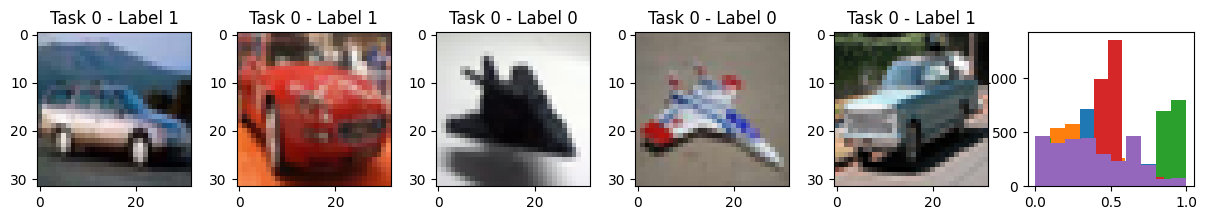

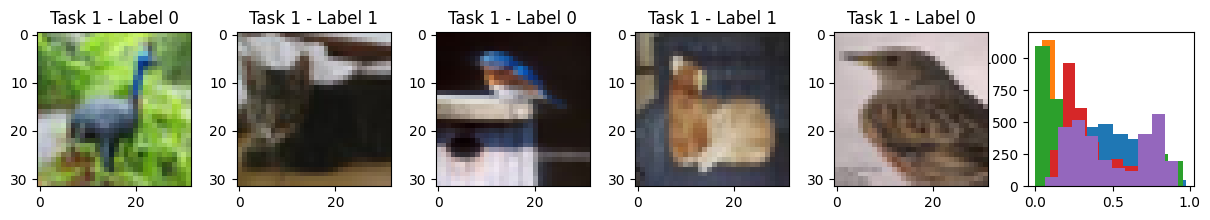

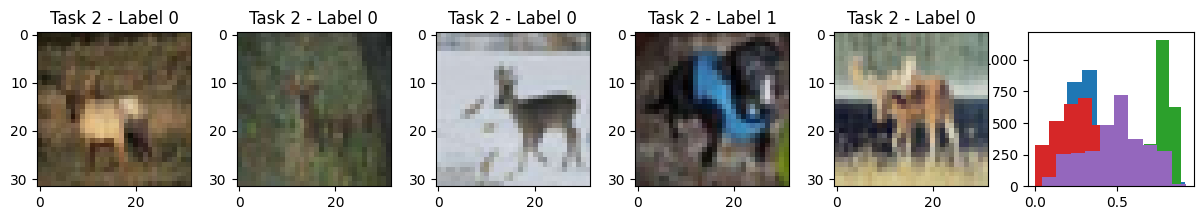

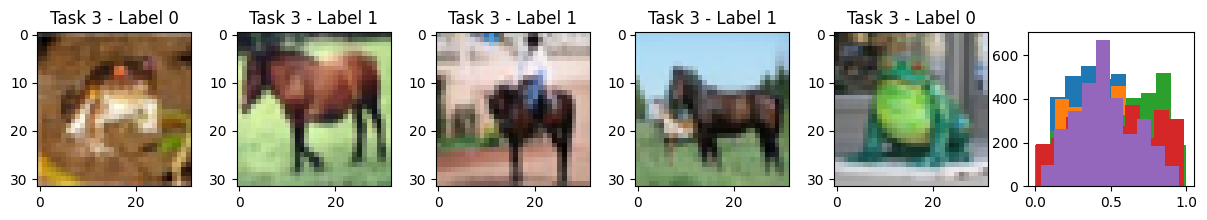

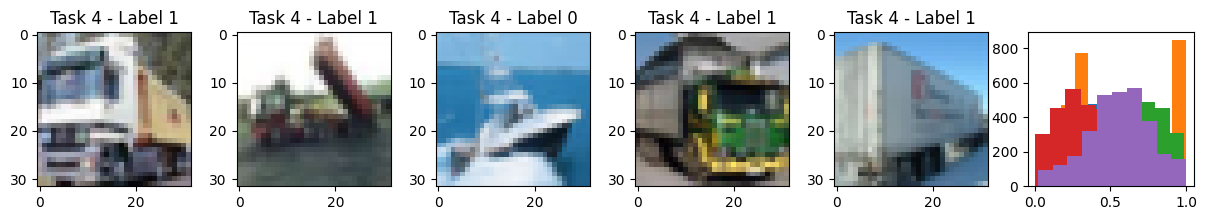

In [ ]:
# task_dataloader = TaskILMNIST(config=config).get_all_tasks_dataloaders()
task_dataloader = TaskILCIFAR10(config=config).get_all_tasks_dataloaders()
visualize_domains(task_dataloader, type = "CIFAR")

## Domain Incremental Learning

Uses all 10 classes in each task. Different "domains" simulated by applying different rotation angles. Model needs to handle same classes with different distributions

torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])


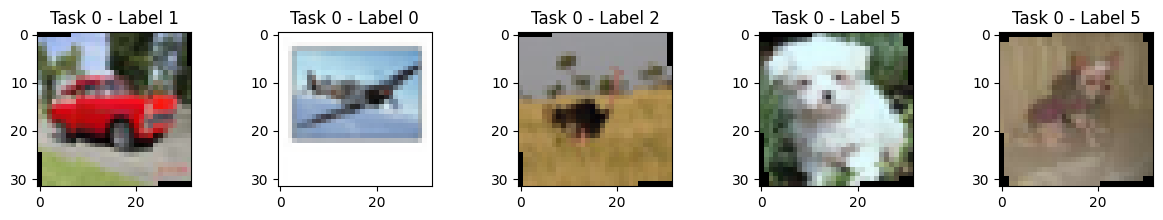

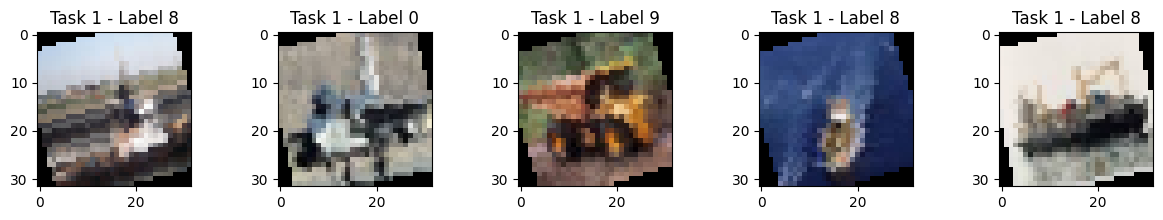

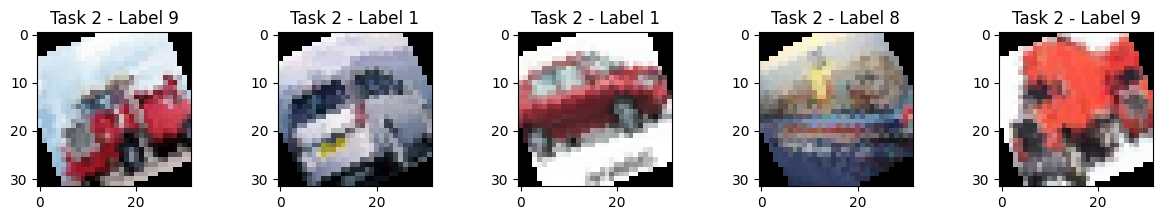

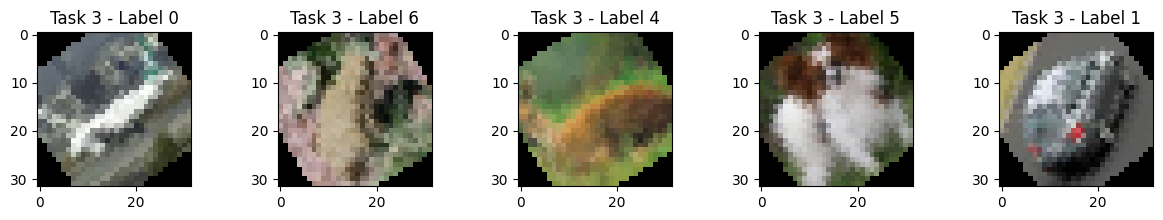

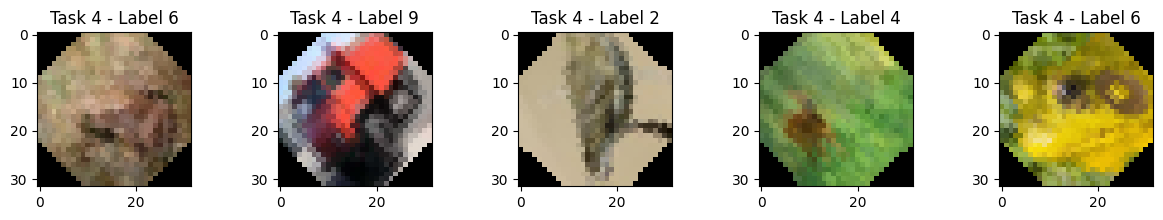

In [24]:
# task_dataloader = DomainILMNIST(config=config).get_all_tasks_dataloaders()
task_dataloader = DomainILCIFAR10(config=config).get_all_tasks_dataloaders()
visualize_domains(task_dataloader, type = "CIFAR")

## Class Incremental Learning

Similar to Task-IL split (2 classes per task). Model learns classes sequentially without task information at test time. 

It remains to be discussed whether the labels must be 0/1 or the "global" ones.

torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])
torch.Size([128, 3, 32, 32])


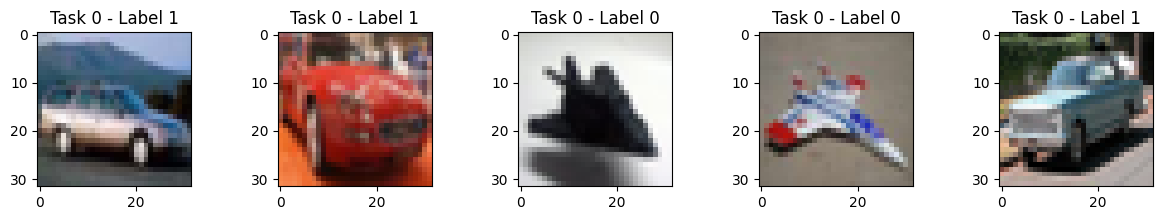

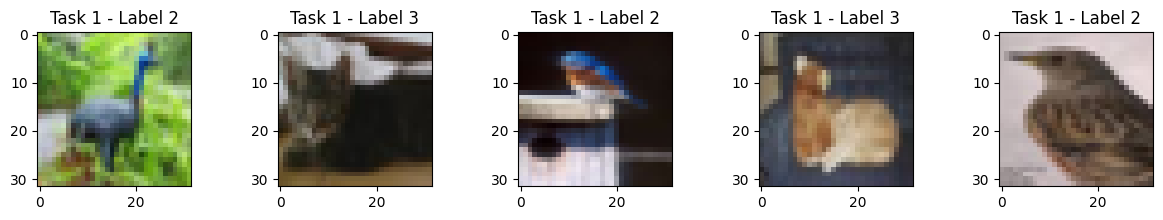

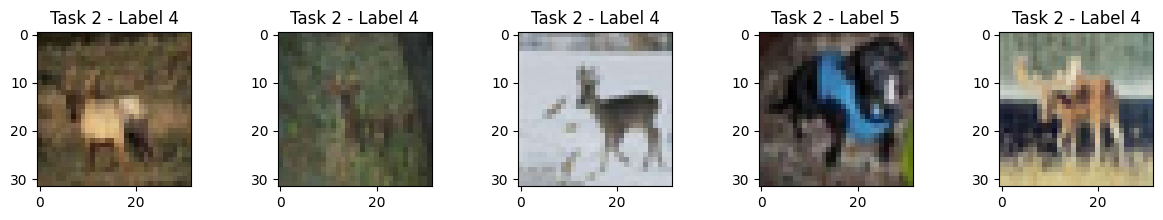

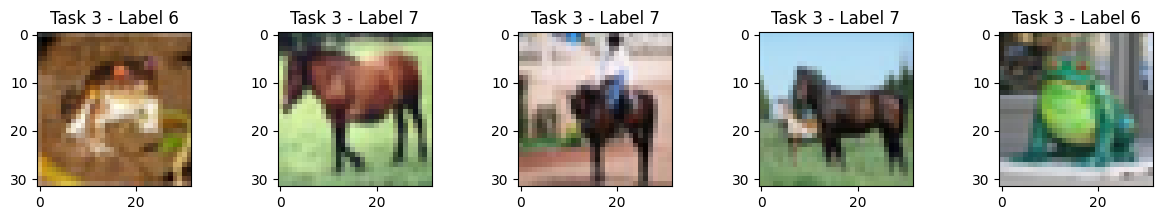

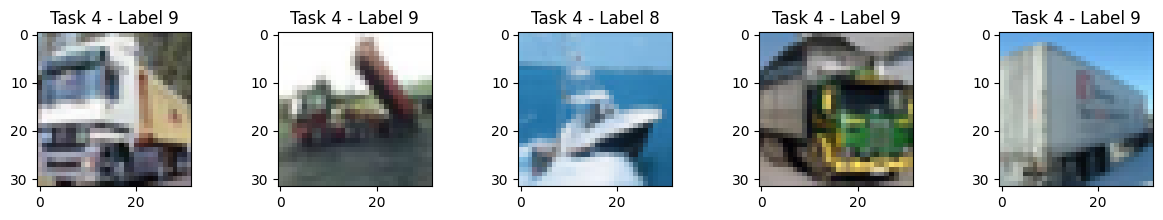

In [ ]:
# task_dataloader = ClassILMNIST(config=config).get_all_tasks_dataloaders()
task_dataloader = ClassILCIFAR10(config=config).get_all_tasks_dataloaders()
visualize_domains(task_dataloader, type = "CIFAR")

# original Split MNIST from Sander

# Check the speed of Dataloaders

In [2]:
## Check speed of dataloader 
import time
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from src.dataloaders import TaskILMNIST, DomainILMNIST, ClassILMNIST
from src.datasets import SplitMNIST
from src.utils import dotdict

config = {
        "batch_size": 128,
        "num_workers": 8,
        "device": "cpu",
        "seed": 1337,
    }
config = dotdict(config)

loaders = [TaskILMNIST, DomainILMNIST, ClassILMNIST, SplitMNIST]
loader_name = ["TaskILMNIST", "DomainILMNIST", "ClassILMNIST", "SplitMNIST"]
for i, loader in enumerate(loaders):
    start = time.time()
    task_dataloader = TaskILMNIST(config=config).get_all_tasks_dataloaders()
    for task_id, (train_loader, test_loader) in enumerate(task_dataloader):
        for img, target in train_loader:
            pass
    print(loader_name[i], time.time() - start)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TaskILMNIST 3.2780637741088867
DomainILMNIST 3.2163641452789307
ClassILMNIST 3.280972480773926
SplitMNIST 3.4139225482940674


# Check output type of dataloaders

In [2]:
task_dataloader = ClassILMNIST(config=config).get_all_tasks_dataloaders()
for task_id, (train_loader, test_loader) in enumerate(task_dataloader):
    batch_img, batch_targets = next(iter(train_loader))
    batch_img = batch_img.reshape(-1, 28, 28)
    for i, target in enumerate(batch_targets):
        if i % 100 == 0:
            print(target)
            print(target.shape, target.argmax())

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
torch.Size([10]) tensor(0)
tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
torch.Size([10]) tensor(1)
tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
torch.Size([10]) tensor(2)
tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
torch.Size([10]) tensor(2)
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
torch.Size([10]) tensor(5)
tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
torch.Size([10]) tensor(4)
tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])
torch.Size([10]) tensor(6)
tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
torch.Size([10]) tensor(7)
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
torch.Size([10]) tensor(9)
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
torch.Size([10]) tensor(9)
